In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import random

import os
import pickle
import cvxpy as cp
from tqdm import tqdm
import seaborn as sns

import matplotlib.dates as mdates
import matplotlib.pyplot as plt

import functions

In [2]:
# load results

with open("results_080726.pkl", "rb") as f:
    results = pickle.load(f)

Computing test scenario matrices...
Done. 60 unique scenario matrices.

300 results: 5 seeds × 12 months × 5 gammas

gamma
0.00    0.900000
0.25    0.883333
0.50    0.900000
0.75    0.900000
1.00    0.866667
Name: cvar_binding, dtype: float64
=== Table 1: Performance Metrics ===
           Cum. Return (↑) Return/CVaR (↑)     Wealth (↑)        MDD (↓)       Regret (↓)          MSE (↓)
γ                                                                                                         
γ=0 (MSE)    0.063 ± 0.164   0.060 ± 0.137  1.063 ± 0.164  0.111 ± 0.055  0.0479 ± 0.0075  0.2051 ± 0.0683
γ=0.25       0.070 ± 0.151   0.067 ± 0.126  1.070 ± 0.151  0.104 ± 0.051  0.0473 ± 0.0069  0.2112 ± 0.0725
γ=0.5        0.061 ± 0.147   0.060 ± 0.124  1.061 ± 0.147  0.111 ± 0.054  0.0479 ± 0.0066  0.2101 ± 0.0705
γ=0.75       0.075 ± 0.138   0.072 ± 0.113  1.075 ± 0.138  0.109 ± 0.053  0.0468 ± 0.0060  0.2169 ± 0.0675
γ=1 (SPO+)   0.079 ± 0.142   0.076 ± 0.117  1.079 ± 0.142  0.102 ± 0.049  0.04

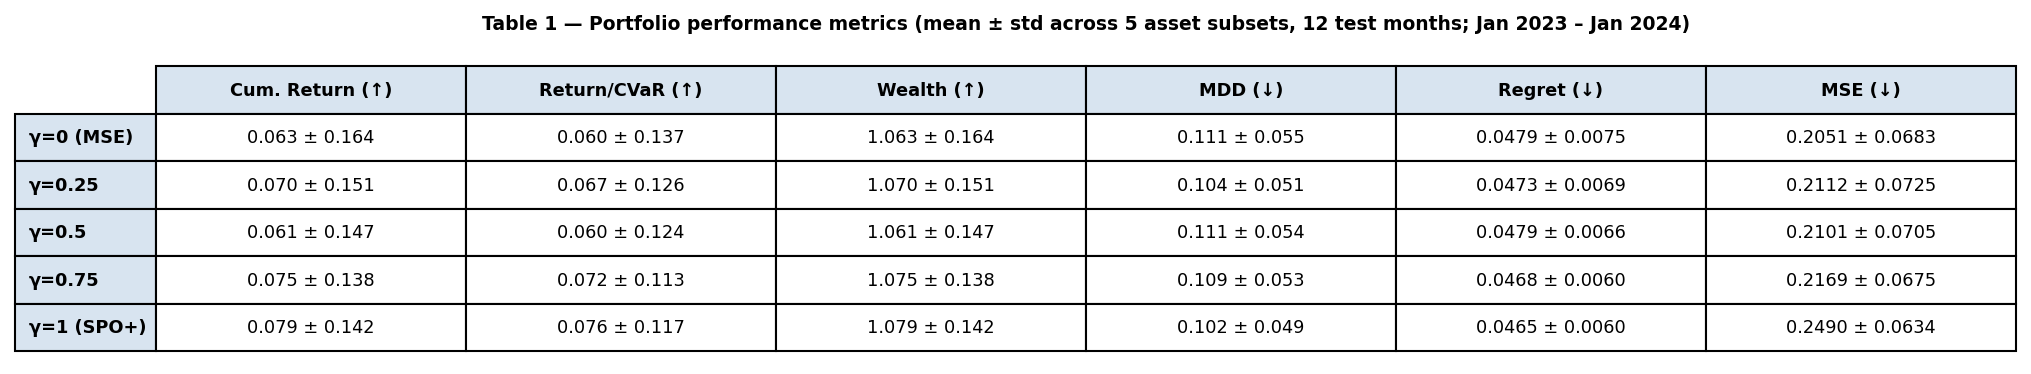

In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import functions

# ─── Constants ────────────────────────────────────────────────────────────────

ALPHA      = 0.95
GAMMAS     = [0.0, 0.25, 0.5, 0.75, 1.0]
GLABELS    = {0.0:  'γ=0 (MSE)', 0.25: 'γ=0.25', 0.5: 'γ=0.5',
              0.75: 'γ=0.75',    1.0:  'γ=1 (SPO+)'}
GSHORT     = {g: f'γ={g}' for g in GAMMAS}
COLORS     = {0.0: '#0072B2', 0.25: '#56B4E9', 0.5: '#009E73',
              0.75: '#E69F00', 1.0: '#D55E00'}
ACTIVE_TOL = 1e-4

plt.rcParams.update({
    'font.size': 9, 'axes.titlesize': 10,
    'axes.labelsize': 9, 'figure.dpi': 150,
})

# subsets saved during experiment
subsets = {
    seed: pd.read_csv(f"../data/processed/return_matrix_random_seed{seed}.csv")
    for seed in range(1, 6)
}

# Pre-compute test scenario matrices (60 unique: 5 seeds × 12 months)

print("Computing test scenario matrices...")
sm_cache = {}
for r in results:
    key = (r['data_seed'], r['test_index'])
    if key not in sm_cache:
        sm_cache[key] = functions.get_scenario_loss_matrix(
            subsets[r['data_seed']],
            r['test_index'],
            num_scenarios=1000,
            random_seed=42
        )
print(f"Done. {len(sm_cache)} unique scenario matrices.\n")

def portfolio_cvar(weights, sm, alpha=ALPHA):
    losses   = sm @ weights
    sorted_l = np.sort(losses)
    k        = int(np.ceil(alpha * len(sorted_l)))
    raw      = float(sorted_l[k:].mean())
    return round(raw, 4)

# ─── Build main dataframe ─────────────────────────────────────────────────────

rows = []
for r in results:
    sm = sm_cache[(r['data_seed'], r['test_index'])]
    w  = r['weights']
    rows.append({
        'data_seed':       r['data_seed'],
        'gamma':           r['gamma'],
        'test_index':      r['test_index'],
        'realized_return': r['realized_return'],
        'oracle_return':   r['oracle_return'],
        'test_regret':     r['test_regret'],
        'test_mse':        r['test_mse'],
        'weights':         w,
        'Y_hat_test':      r['Y_hat_test'],
        'Y_test':          r['Y_test'],
        'best_epoch':      r['best_epoch'],
        'realized_cvar':   portfolio_cvar(w, sm),
        'n_active':        int(np.sum(np.abs(w) > ACTIVE_TOL)),
        'active_mask':     tuple((np.abs(w) > ACTIVE_TOL).astype(int)),
    })

df = pd.DataFrame(rows)
print(f"{len(df)} results: {df['data_seed'].nunique()} seeds × "
      f"{df['test_index'].nunique()} months × {df['gamma'].nunique()} gammas\n")

# What fraction of portfolios have CVaR exactly at the constraint?
df['cvar_binding'] = df['realized_cvar'].apply(
    lambda c: abs(c - 0.09) < 1e-4
)
print(df.groupby('gamma')['cvar_binding'].mean())

# ─── Per-seed time-series metrics ─────────────────────────────────────────────
# Aggregate 12 monthly returns per (data_seed, gamma) in chronological order
# (higher test_index = earlier calendar date → sort descending)

seed_rows = []
for seed in range(1, 6):
    for g in GAMMAS:
        sub  = df[(df['data_seed'] == seed) & (df['gamma'] == g)]
        sub  = sub.sort_values('test_index', ascending=False)
        rets  = sub['realized_return'].values
        cvars = sub['realized_cvar'].values

        # MDD
        cum  = np.cumprod(1 + rets)
        peak = np.maximum.accumulate(cum)
        dd   = (cum - peak) / peak

        seed_rows.append({
            'data_seed':     seed,
            'gamma':         g,
            'cum_return':    float(np.prod(1 + rets) - 1),   # = wealth - 1
            'ret_cvar_ratio':float(rets.mean() / cvars.mean()),
            'wealth':        float(np.prod(1 + rets)),
            'mdd':           float(-dd.min()),
            'mean_regret':   sub['test_regret'].mean(),
            'mean_mse':      sub['test_mse'].mean(),
        })

sm_df = pd.DataFrame(seed_rows)


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 1: Performance metrics table  (Lee et al. Table 2)
# ═════════════════════════════════════════════════════════════════════════════

def fmt(series, dec=3):
    return f"{series.mean():.{dec}f} ± {series.std():.{dec}f}"

tbl_rows = []
cols_def = [
    ('Cum. Return (↑)',  'cum_return',     3),
    ('Return/CVaR (↑)', 'ret_cvar_ratio',  3),
    ('Wealth (↑)',       'wealth',          3),
    ('MDD (↓)',          'mdd',             3),
    ('Regret (↓)',       'mean_regret',     4),
    ('MSE (↓)',          'mean_mse',        4),
]

for g in GAMMAS:
    sub = sm_df[sm_df['gamma'] == g]
    row = {'γ': GLABELS[g]}
    for col_name, col_key, dec in cols_def:
        row[col_name] = fmt(sub[col_key], dec)
    tbl_rows.append(row)

tbl = pd.DataFrame(tbl_rows).set_index('γ')
print("=== Table 1: Performance Metrics ===")
print(tbl.to_string())
print()

fig, ax = plt.subplots(figsize=(16, 2.6))
ax.axis('off')
t = ax.table(
    cellText  = tbl.values,
    colLabels = tbl.columns,
    rowLabels = tbl.index,
    cellLoc   = 'center',
    loc       = 'center',
)
t.auto_set_font_size(False)
t.set_fontsize(8.5)
t.scale(1, 1.9)
for (row, col), cell in t.get_celld().items():
    if row == 0 or col == -1:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#D8E4F0')
ax.set_title(
    'Table 1 — Portfolio performance metrics (mean ± std across 5 asset subsets, '
    '12 test months; Jan 2023 – Jan 2024)',
    fontsize=9, fontweight='bold', pad=14,
)
plt.savefig('table1_performance.pdf', bbox_inches='tight')
plt.show()

In [8]:
sm_df

,data_seed,gamma,cum_return,ret_cvar_ratio,wealth,mdd,mean_regret,mean_mse
0,1,0.00,0.316621,0.265586,1.316621,0.025132,0.038613,0.167149
1,1,0.25,0.290219,0.246032,1.290219,0.025132,0.040357,0.154256
2,1,0.50,0.282324,0.240579,1.282324,0.025132,0.040844,0.139175
3,1,0.75,0.294060,0.249082,1.294060,0.025132,0.040085,0.161943
4,1,1.00,0.300355,0.254106,1.300355,0.025132,0.039637,0.186954
5,2,0.00,-0.054032,-0.038502,0.945968,0.176514,0.055477,0.292100
6,2,0.25,-0.039106,-0.023966,0.960894,0.165859,0.054167,0.293705
7,2,0.50,-0.051724,-0.035967,0.948276,0.176285,0.055249,0.286983
8,2,0.75,-0.050610,-0.035139,0.949390,0.173683,0.055174,0.293353
9,2,1.00,-0.032687,-0.017876,0.967313,0.162048,0.053620,0.322542


Computing test scenario matrices...
Done. 60 unique scenario matrices.

300 results: 5 seeds × 12 months × 5 gammas

=== Table 1: Performance Metrics ===
           Cum. Return (↑) Return/CVaR (↑)     Wealth (↑)        MDD (↓)       Regret (↓)          MSE (↓)
γ                                                                                                         
γ=0 (MSE)    0.063 ± 0.164   0.060 ± 0.137  1.063 ± 0.164  0.111 ± 0.055  0.0479 ± 0.0075  0.2051 ± 0.0683
γ=0.25       0.070 ± 0.151   0.067 ± 0.126  1.070 ± 0.151  0.104 ± 0.051  0.0473 ± 0.0069  0.2112 ± 0.0725
γ=0.5        0.061 ± 0.147   0.060 ± 0.124  1.061 ± 0.147  0.111 ± 0.054  0.0479 ± 0.0066  0.2101 ± 0.0705
γ=0.75       0.075 ± 0.138   0.072 ± 0.113  1.075 ± 0.138  0.109 ± 0.053  0.0468 ± 0.0060  0.2169 ± 0.0675
γ=1 (SPO+)   0.079 ± 0.142   0.076 ± 0.117  1.079 ± 0.142  0.102 ± 0.049  0.0465 ± 0.0060  0.2490 ± 0.0634



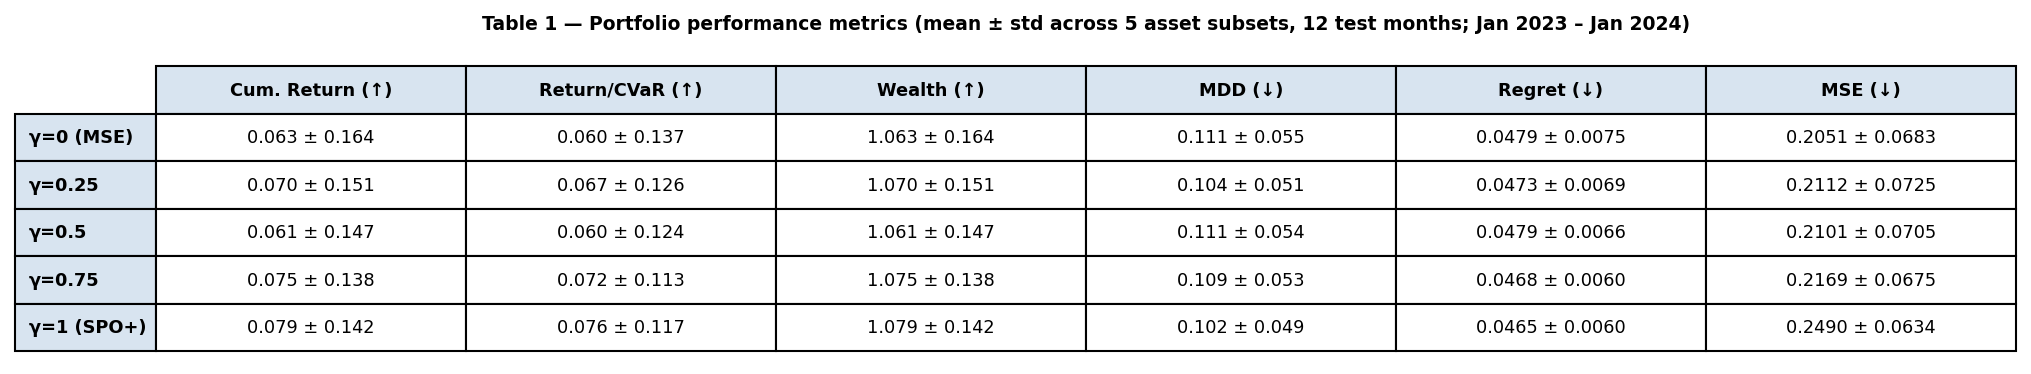

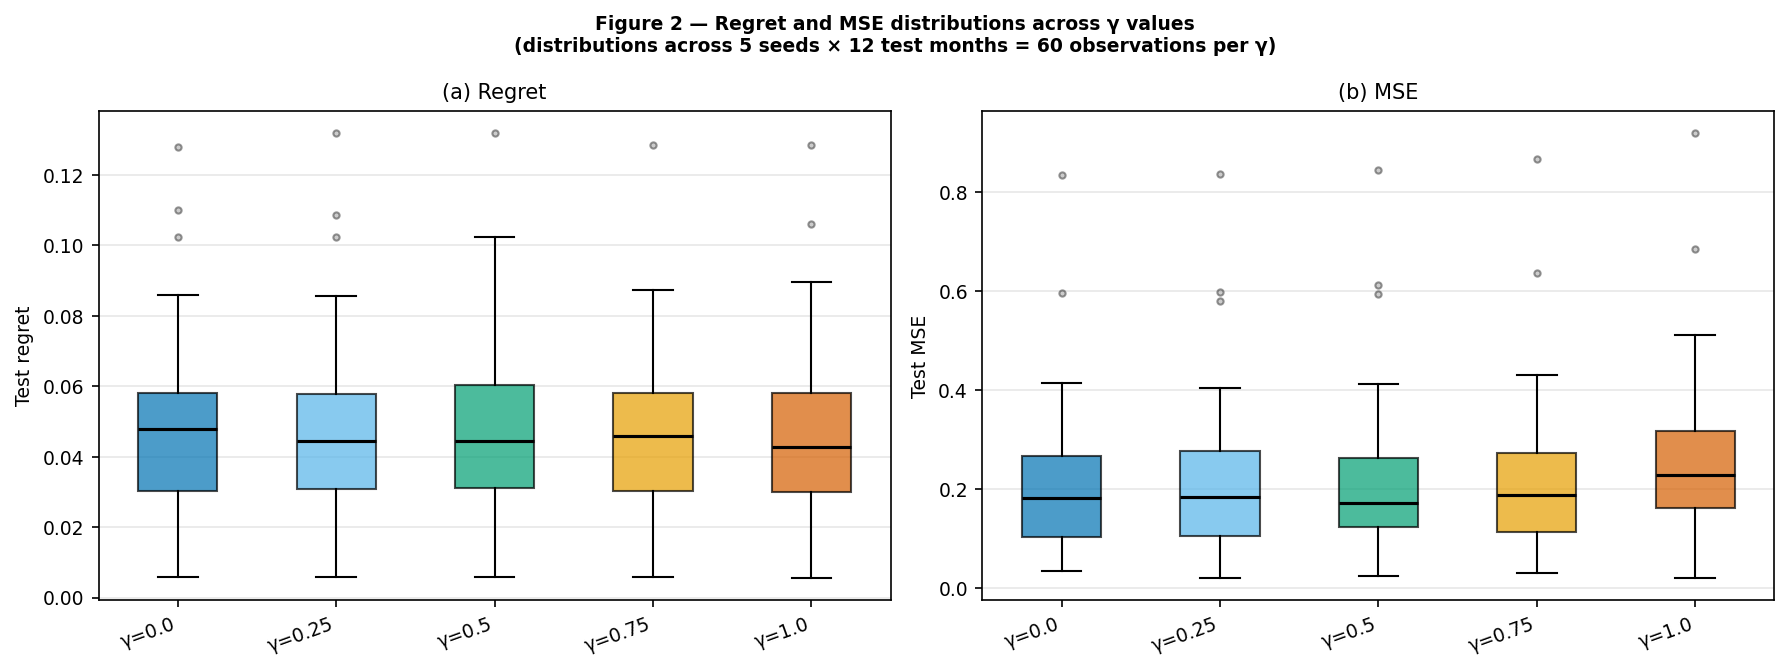

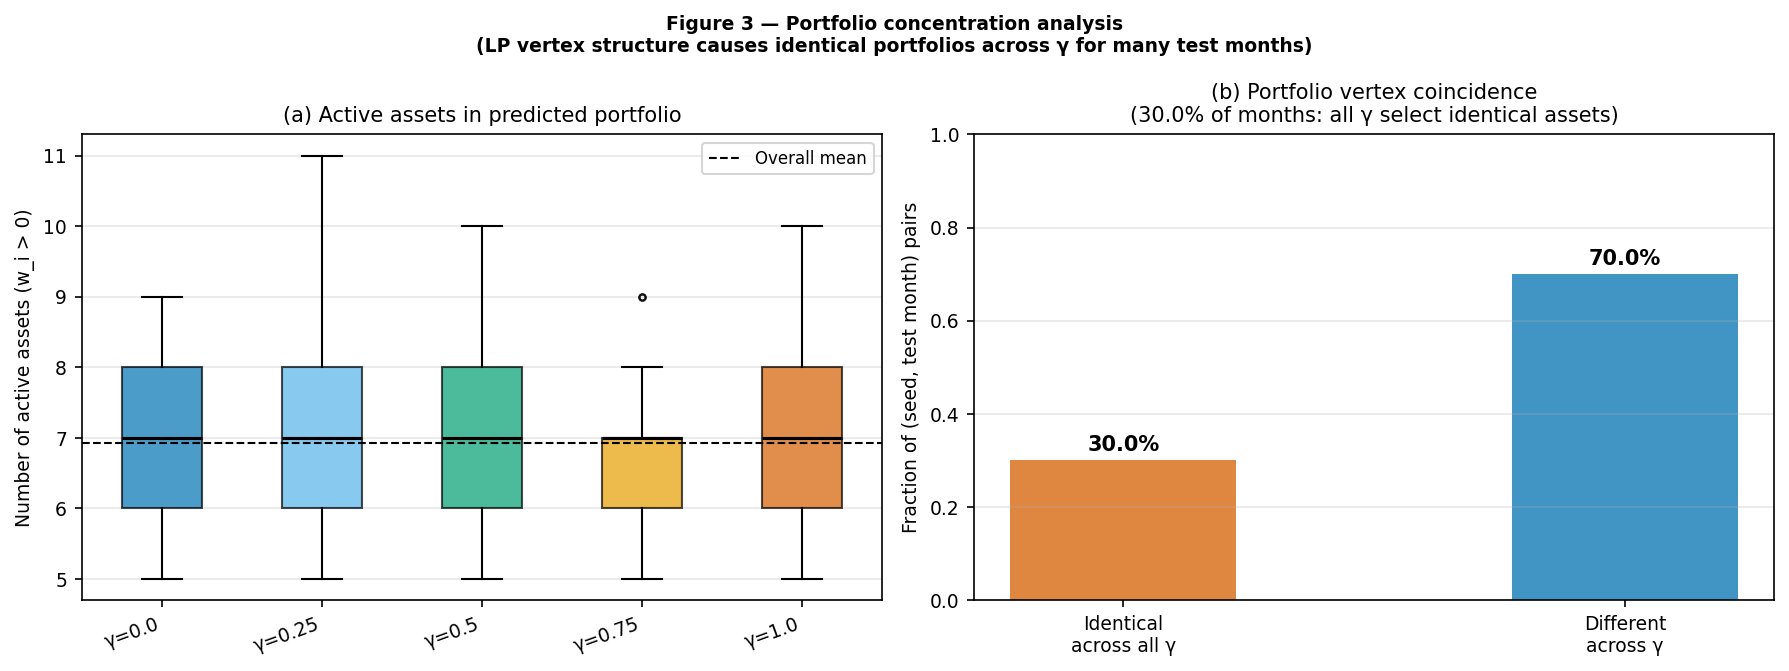

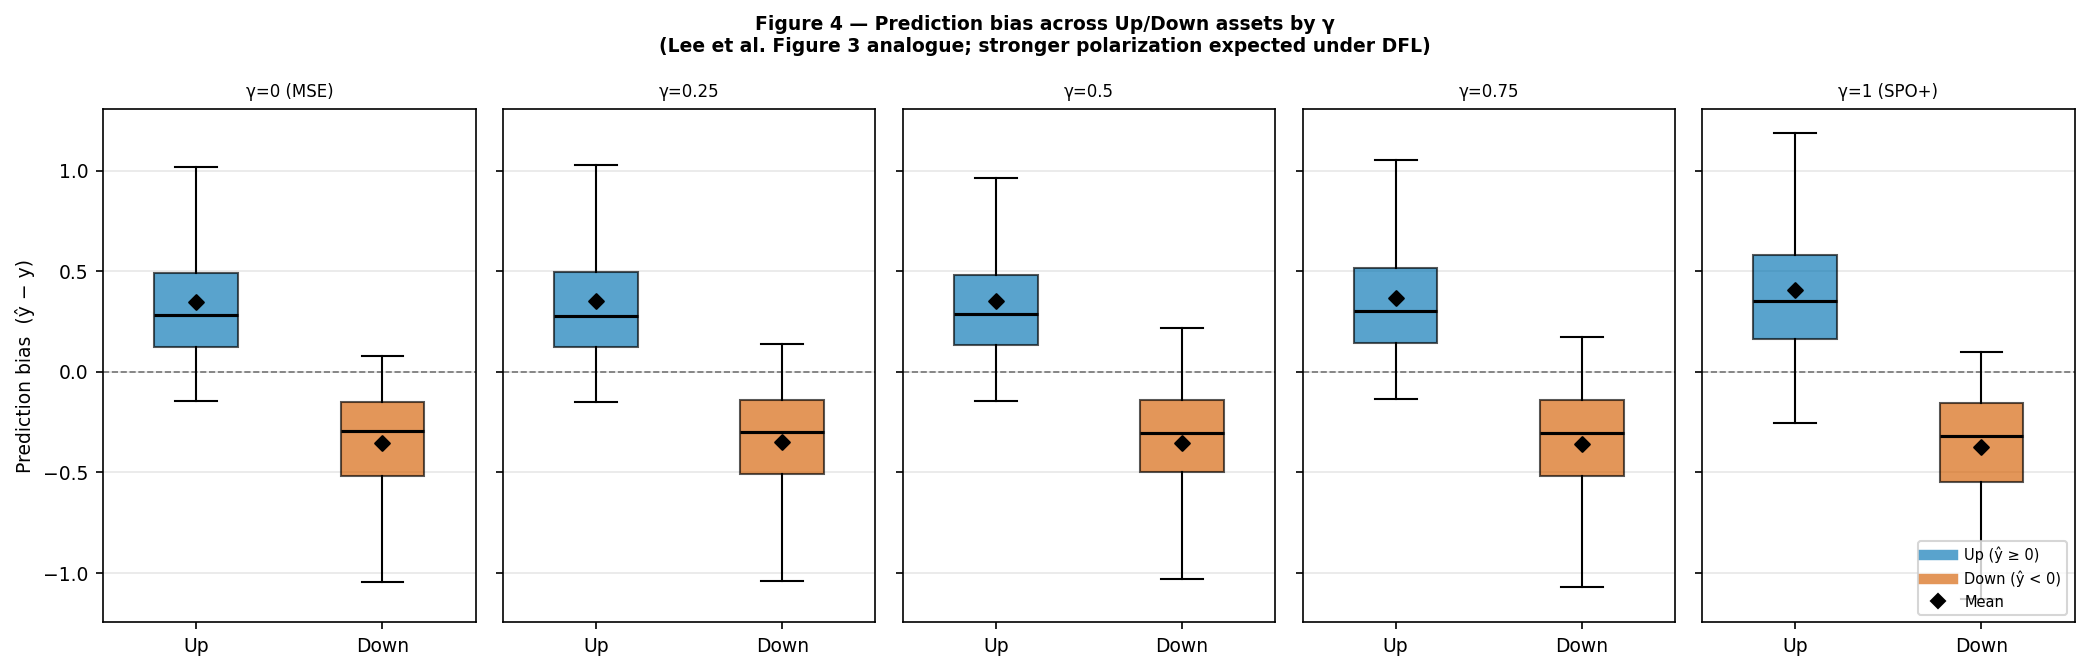

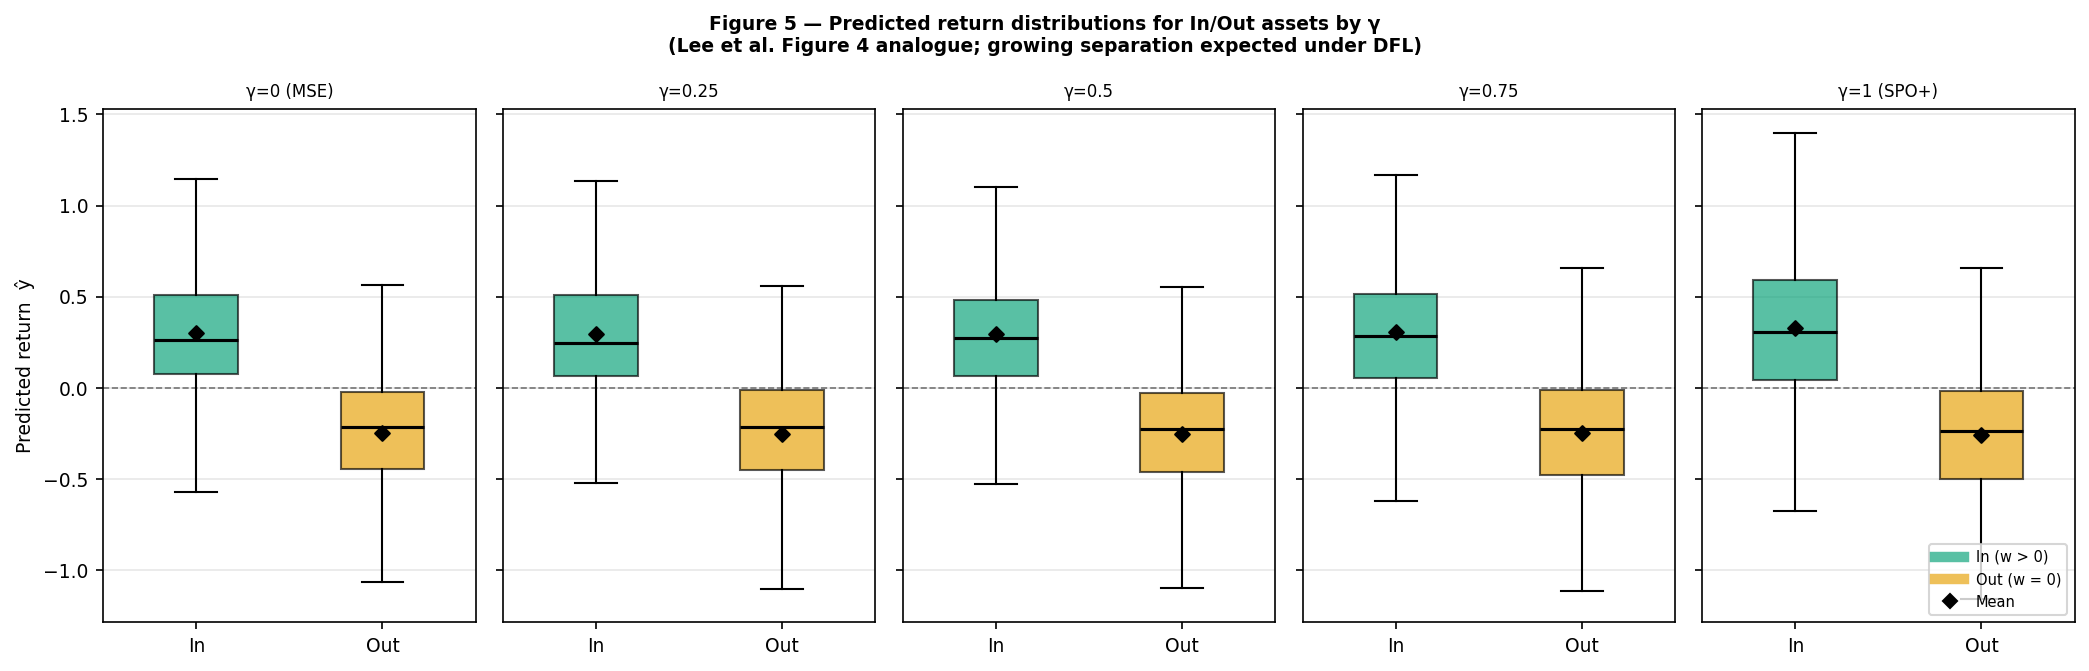

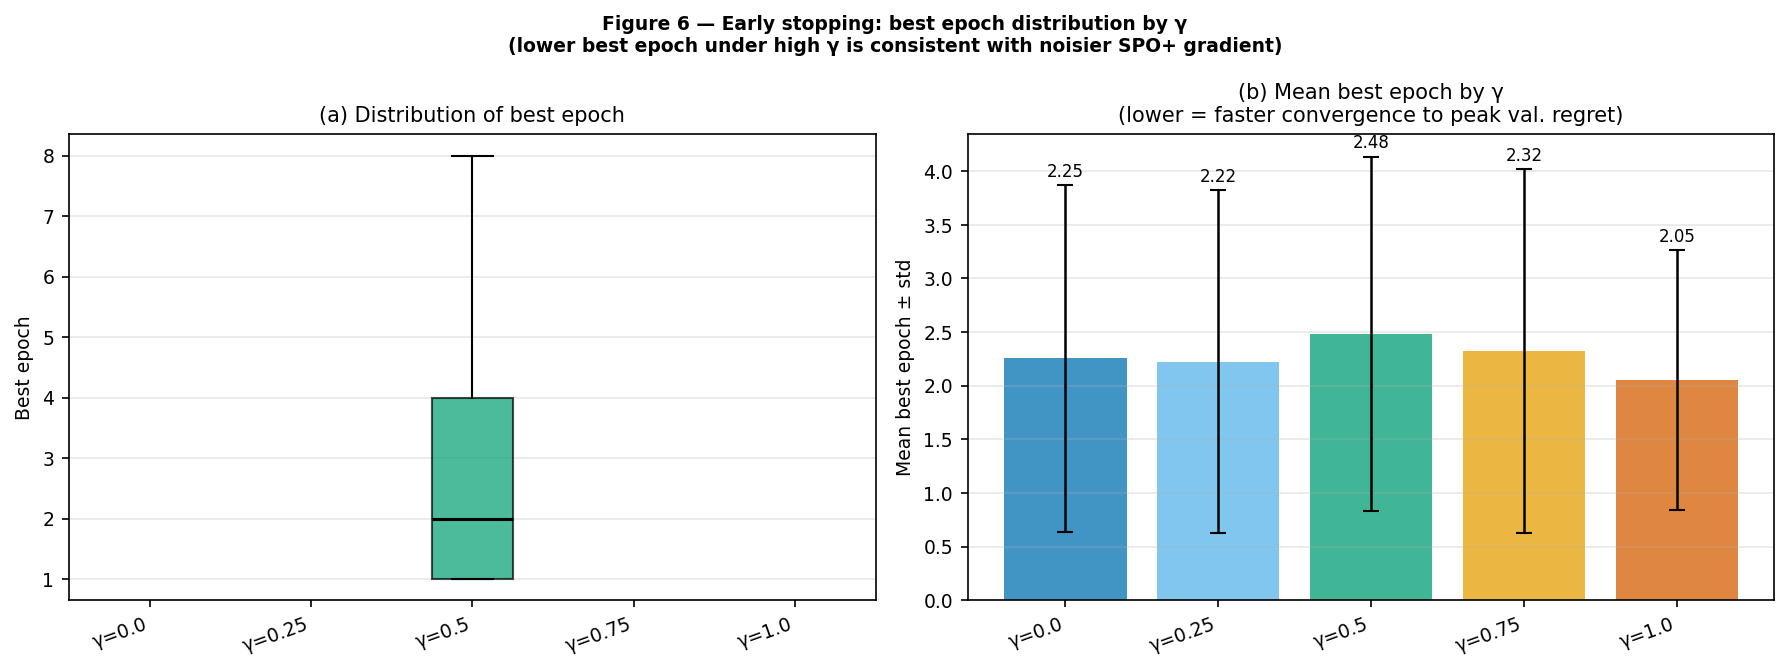

All figures saved.


In [6]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import functions

# ─── Constants ────────────────────────────────────────────────────────────────

ALPHA      = 0.95
GAMMAS     = [0.0, 0.25, 0.5, 0.75, 1.0]
GLABELS    = {0.0:  'γ=0 (MSE)', 0.25: 'γ=0.25', 0.5: 'γ=0.5',
              0.75: 'γ=0.75',    1.0:  'γ=1 (SPO+)'}
GSHORT     = {g: f'γ={g}' for g in GAMMAS}
COLORS     = {0.0: '#0072B2', 0.25: '#56B4E9', 0.5: '#009E73',
              0.75: '#E69F00', 1.0: '#D55E00'}
ACTIVE_TOL = 1e-4

plt.rcParams.update({
    'font.size': 9, 'axes.titlesize': 10,
    'axes.labelsize': 9, 'figure.dpi': 150,
})

# subsets saved during experiment
subsets = {
    seed: pd.read_csv(f"../data/processed/return_matrix_random_seed{seed}.csv")
    for seed in range(1, 6)
}

# ─── Pre-compute test scenario matrices (60 unique: 5 seeds × 12 months) ─────

print("Computing test scenario matrices...")
sm_cache = {}
for r in results:
    key = (r['data_seed'], r['test_index'])
    if key not in sm_cache:
        sm_cache[key] = functions.get_scenario_loss_matrix(
            subsets[r['data_seed']],
            r['test_index'],
            num_scenarios=1000,
            random_seed=42
        )
print(f"Done. {len(sm_cache)} unique scenario matrices.\n")

# ─── CVaR helper (follows CVaRSolver.compute_cvar exactly) ───────────────────

def portfolio_cvar(weights, sm, alpha=ALPHA):
    losses   = sm @ weights
    sorted_l = np.sort(losses)
    k        = int(np.ceil(alpha * len(sorted_l)))
    return float(sorted_l[k:].mean())

# ─── Build main dataframe ─────────────────────────────────────────────────────

rows = []
for r in results:
    sm = sm_cache[(r['data_seed'], r['test_index'])]
    w  = r['weights']
    rows.append({
        'data_seed':       r['data_seed'],
        'gamma':           r['gamma'],
        'test_index':      r['test_index'],
        'realized_return': r['realized_return'],
        'oracle_return':   r['oracle_return'],
        'test_regret':     r['test_regret'],
        'test_mse':        r['test_mse'],
        'weights':         w,
        'Y_hat_test':      r['Y_hat_test'],
        'Y_test':          r['Y_test'],
        'best_epoch':      r['best_epoch'],
        'realized_cvar':   portfolio_cvar(w, sm),
        'n_active':        int(np.sum(np.abs(w) > ACTIVE_TOL)),
        'active_mask':     tuple((np.abs(w) > ACTIVE_TOL).astype(int)),
    })

df = pd.DataFrame(rows)
print(f"{len(df)} results: {df['data_seed'].nunique()} seeds × "
      f"{df['test_index'].nunique()} months × {df['gamma'].nunique()} gammas\n")

# ─── Per-seed time-series metrics ─────────────────────────────────────────────
# Aggregate 12 monthly returns per (data_seed, gamma) in chronological order
# (higher test_index = earlier calendar date → sort descending)

seed_rows = []
for seed in range(1, 6):
    for g in GAMMAS:
        sub  = df[(df['data_seed'] == seed) & (df['gamma'] == g)]
        sub  = sub.sort_values('test_index', ascending=False)
        rets  = sub['realized_return'].values
        cvars = sub['realized_cvar'].values

        # MDD
        cum  = np.cumprod(1 + rets)
        peak = np.maximum.accumulate(cum)
        dd   = (cum - peak) / peak

        seed_rows.append({
            'data_seed':     seed,
            'gamma':         g,
            'cum_return':    float(np.prod(1 + rets) - 1),   # = wealth - 1
            'ret_cvar_ratio':float(rets.mean() / cvars.mean()),
            'wealth':        float(np.prod(1 + rets)),
            'mdd':           float(-dd.min()),
            'mean_regret':   sub['test_regret'].mean(),
            'mean_mse':      sub['test_mse'].mean(),
        })

sm_df = pd.DataFrame(seed_rows)


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 1: Performance metrics table  (Lee et al. Table 2)
# ═════════════════════════════════════════════════════════════════════════════

def fmt(series, dec=3):
    return f"{series.mean():.{dec}f} ± {series.std():.{dec}f}"

tbl_rows = []
cols_def = [
    ('Cum. Return (↑)',  'cum_return',     3),
    ('Return/CVaR (↑)', 'ret_cvar_ratio',  3),
    ('Wealth (↑)',       'wealth',          3),
    ('MDD (↓)',          'mdd',             3),
    ('Regret (↓)',       'mean_regret',     4),
    ('MSE (↓)',          'mean_mse',        4),
]

for g in GAMMAS:
    sub = sm_df[sm_df['gamma'] == g]
    row = {'γ': GLABELS[g]}
    for col_name, col_key, dec in cols_def:
        row[col_name] = fmt(sub[col_key], dec)
    tbl_rows.append(row)

tbl = pd.DataFrame(tbl_rows).set_index('γ')
print("=== Table 1: Performance Metrics ===")
print(tbl.to_string())
print()

fig, ax = plt.subplots(figsize=(16, 2.6))
ax.axis('off')
t = ax.table(
    cellText  = tbl.values,
    colLabels = tbl.columns,
    rowLabels = tbl.index,
    cellLoc   = 'center',
    loc       = 'center',
)
t.auto_set_font_size(False)
t.set_fontsize(8.5)
t.scale(1, 1.9)
for (row, col), cell in t.get_celld().items():
    if row == 0 or col == -1:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#D8E4F0')
ax.set_title(
    'Table 1 — Portfolio performance metrics (mean ± std across 5 asset subsets, '
    '12 test months; Jan 2023 – Jan 2024)',
    fontsize=9, fontweight='bold', pad=14,
)
plt.savefig('table1_performance.pdf', bbox_inches='tight')
plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 2: Regret and MSE distributions  (Lee et al. Figure 2)
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
labels = [GSHORT[g] for g in GAMMAS]

for ax, col, ylabel, title in zip(
    axes,
    ['test_regret', 'test_mse'],
    ['Test regret', 'Test MSE'],
    ['(a) Regret', '(b) MSE'],
):
    data = [df[df['gamma'] == g][col].values for g in GAMMAS]
    bp   = ax.boxplot(
        data, patch_artist=True, widths=0.5,
        medianprops=dict(color='black', linewidth=1.5),
        flierprops=dict(marker='o', markersize=3, alpha=0.4, markerfacecolor='grey'),
    )
    for patch, g in zip(bp['boxes'], GAMMAS):
        patch.set_facecolor(COLORS[g])
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, len(GAMMAS)+1))
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Figure 2 — Regret and MSE distributions across γ values\n'
    '(distributions across 5 seeds × 12 test months = 60 observations per γ)',
    fontsize=9, fontweight='bold',
)
plt.tight_layout()
plt.savefig('fig2_regret_mse.pdf', bbox_inches='tight')
plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 3: Portfolio concentration
# ═════════════════════════════════════════════════════════════════════════════

# Fraction of (data_seed, test_index) pairs where all γ produce same asset mask
identical = (
    df.groupby(['data_seed', 'test_index'])['active_mask']
    .apply(lambda x: len(set(x.values)) == 1)
)
frac_identical = float(identical.mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: number of active assets by gamma
data_n = [df[df['gamma'] == g]['n_active'].values for g in GAMMAS]
bp = axes[0].boxplot(
    data_n, patch_artist=True, widths=0.5,
    medianprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
)
for patch, g in zip(bp['boxes'], GAMMAS):
    patch.set_facecolor(COLORS[g])
    patch.set_alpha(0.7)
oracle_mean = df.groupby(['data_seed', 'test_index'])['active_mask'].first().apply(
    lambda m: sum(m)
).mean()   # n_active of oracle is same for all gammas in a given month
axes[0].axhline(
    df['n_active'].groupby(df.groupby(['data_seed','test_index']).ngroup()).mean().mean(),
    color='black', linestyle='--', linewidth=1, label='Overall mean'
)
axes[0].set_xticks(range(1, len(GAMMAS)+1))
axes[0].set_xticklabels(labels, rotation=20, ha='right')
axes[0].set_ylabel('Number of active assets (w_i > 0)')
axes[0].set_title('(a) Active assets in predicted portfolio')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Right: fraction of months with identical portfolios across all gamma
bars = axes[1].bar(
    ['Identical\nacross all γ', 'Different\nacross γ'],
    [frac_identical, 1 - frac_identical],
    color=['#D55E00', '#0072B2'], alpha=0.75, width=0.45,
)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Fraction of (seed, test month) pairs')
axes[1].set_title(
    f'(b) Portfolio vertex coincidence\n'
    f'({frac_identical:.1%} of months: all γ select identical assets)'
)
for bar, v in zip(bars, [frac_identical, 1 - frac_identical]):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02,
                 f'{v:.1%}', ha='center', fontsize=10, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle(
    'Figure 3 — Portfolio concentration analysis\n'
    '(LP vertex structure causes identical portfolios across γ for many test months)',
    fontsize=9, fontweight='bold',
)
plt.tight_layout()
plt.savefig('fig3_concentration.pdf', bbox_inches='tight')
plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 4: Prediction bias — Up vs Down assets  (Lee et al. Figure 3)
# ═════════════════════════════════════════════════════════════════════════════
# Up  = assets where Y_hat >= 0 (model predicts positive return)
# Down = assets where Y_hat < 0 (model predicts negative return)
# Bias = Y_hat - Y_true

updown = {g: {'up': [], 'down': []} for g in GAMMAS}
for _, row in df.iterrows():
    bias   = row['Y_hat_test'] - row['Y_test']
    is_up  = row['Y_hat_test'] >= 0
    updown[row['gamma']]['up'].extend(bias[is_up].tolist())
    updown[row['gamma']]['down'].extend(bias[~is_up].tolist())

fig, axes = plt.subplots(1, len(GAMMAS), figsize=(14, 4.5), sharey=True)

for ax, g in zip(axes, GAMMAS):
    data = [updown[g]['up'], updown[g]['down']]
    bp = ax.boxplot(
        data, patch_artist=True, widths=0.45,
        medianprops=dict(color='black', linewidth=1.5),
        flierprops=dict(marker='o', markersize=2, alpha=0.2),
        showfliers=False,
    )
    bp['boxes'][0].set_facecolor('#0072B2'); bp['boxes'][0].set_alpha(0.65)
    bp['boxes'][1].set_facecolor('#D55E00'); bp['boxes'][1].set_alpha(0.65)

    # Mark means
    for i, lst in enumerate(data, 1):
        ax.scatter(i, np.mean(lst), marker='D', s=25, zorder=3,
                   color='black')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Up', 'Down'])
    ax.set_title(GLABELS[g], fontsize=8)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Prediction bias  (ŷ − y)')
legend_elements = [
    Line2D([0],[0], color='#0072B2', lw=5, alpha=0.65, label='Up (ŷ ≥ 0)'),
    Line2D([0],[0], color='#D55E00', lw=5, alpha=0.65, label='Down (ŷ < 0)'),
    Line2D([0],[0], marker='D', color='black', lw=0, markersize=5, label='Mean'),
]
axes[-1].legend(handles=legend_elements, fontsize=7, loc='lower right')

fig.suptitle(
    'Figure 4 — Prediction bias across Up/Down assets by γ\n'
    '(Lee et al. Figure 3 analogue; stronger polarization expected under DFL)',
    fontsize=9, fontweight='bold',
)
plt.tight_layout()
plt.savefig('fig4_bias_updown.pdf', bbox_inches='tight')
plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 5: Predicted returns — In vs Out assets  (Lee et al. Figure 4)
# ═════════════════════════════════════════════════════════════════════════════
# In  = assets selected in portfolio (weight > tol)
# Out = assets excluded from portfolio

inout = {g: {'in': [], 'out': []} for g in GAMMAS}
for _, row in df.iterrows():
    yhat  = row['Y_hat_test']
    is_in = np.abs(row['weights']) > ACTIVE_TOL
    inout[row['gamma']]['in'].extend(yhat[is_in].tolist())
    inout[row['gamma']]['out'].extend(yhat[~is_in].tolist())

fig, axes = plt.subplots(1, len(GAMMAS), figsize=(14, 4.5), sharey=True)

for ax, g in zip(axes, GAMMAS):
    data = [inout[g]['in'], inout[g]['out']]
    bp = ax.boxplot(
        data, patch_artist=True, widths=0.45,
        medianprops=dict(color='black', linewidth=1.5),
        flierprops=dict(marker='o', markersize=2, alpha=0.2),
        showfliers=False,
    )
    bp['boxes'][0].set_facecolor('#009E73'); bp['boxes'][0].set_alpha(0.65)
    bp['boxes'][1].set_facecolor('#E69F00'); bp['boxes'][1].set_alpha(0.65)

    for i, lst in enumerate(data, 1):
        ax.scatter(i, np.mean(lst), marker='D', s=25, zorder=3, color='black')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['In', 'Out'])
    ax.set_title(GLABELS[g], fontsize=8)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Predicted return  ŷ')
legend_elements = [
    Line2D([0],[0], color='#009E73', lw=5, alpha=0.65, label='In (w > 0)'),
    Line2D([0],[0], color='#E69F00', lw=5, alpha=0.65, label='Out (w = 0)'),
    Line2D([0],[0], marker='D', color='black', lw=0, markersize=5, label='Mean'),
]
axes[-1].legend(handles=legend_elements, fontsize=7, loc='lower right')

fig.suptitle(
    'Figure 5 — Predicted return distributions for In/Out assets by γ\n'
    '(Lee et al. Figure 4 analogue; growing separation expected under DFL)',
    fontsize=9, fontweight='bold',
)
plt.tight_layout()
plt.savefig('fig5_inout_returns.pdf', bbox_inches='tight')
plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 6: Best epoch distribution  (thesis-specific diagnostic)
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: box plot
data_ep = [df[df['gamma'] == g]['best_epoch'].values for g in GAMMAS]
bp = axes[0].boxplot(
    data_ep, patch_artist=True, widths=0.5,
    medianprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
)
for patch, g in zip(bp['boxes'], GAMMAS):
    patch.set_facecolor(COLORS[g])
    patch.set_alpha(0.7)
axes[0].set_xticks(range(1, len(GAMMAS)+1))
axes[0].set_xticklabels(labels, rotation=20, ha='right')
axes[0].set_ylabel('Best epoch')
axes[0].set_title('(a) Distribution of best epoch')
axes[0].grid(axis='y', alpha=0.3)

# Right: mean ± std bar chart
means = [df[df['gamma'] == g]['best_epoch'].mean() for g in GAMMAS]
stds  = [df[df['gamma'] == g]['best_epoch'].std()  for g in GAMMAS]
x = np.arange(len(GAMMAS))
axes[1].bar(
    x, means, yerr=stds, capsize=4, alpha=0.75,
    color=[COLORS[g] for g in GAMMAS],
    error_kw=dict(elinewidth=1.2, ecolor='black'),
)
for i, (m, s) in enumerate(zip(means, stds)):
    axes[1].text(i, m + s + 0.08, f'{m:.2f}', ha='center', fontsize=8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, rotation=20, ha='right')
axes[1].set_ylabel('Mean best epoch ± std')
axes[1].set_title('(b) Mean best epoch by γ\n(lower = faster convergence to peak val. regret)')
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle(
    'Figure 6 — Early stopping: best epoch distribution by γ\n'
    '(lower best epoch under high γ is consistent with noisier SPO+ gradient)',
    fontsize=9, fontweight='bold',
)
plt.tight_layout()
plt.savefig('fig6_best_epoch.pdf', bbox_inches='tight')
plt.show()

print("All figures saved.")

In [3]:
results

[{'run_id': 'seed1_g0_t1_b0.09',
  'data_seed': 1,
  'beta': 0.09,
  'gamma': 0,
  'test_index': 1,
  'n_train': 279,
  'n_assets': 15,
  'n_scenarios': 1000,
  'spo_scale': np.float64(0.9986290560429176),
  'mse_scale': np.float64(0.35381100492344963),
  'Y_hat_test': array([-0.4066921 ,  0.44550803, -0.25962782, -0.29390946,  0.4328537 ,
          0.31965566, -0.28420988, -0.21525411,  0.15184934, -0.8064906 ,
          0.20778704,  0.19040468, -0.8616894 , -0.15610647,  0.5398214 ],
        dtype=float32),
  'Y_test': array([ 0.06263721, -0.0040937 , -0.04385215,  0.06797651,  0.02032161,
         -0.0495874 , -0.00514266, -0.01352265,  0.03680063, -0.01431667,
         -0.00076948, -0.01120596,  0.1246969 ,  0.03237282,  0.05350714]),
  'test_mse': np.float64(0.19966212454507742),
  'weights': array([-0.        ,  0.2       , -0.        , -0.        ,  0.2       ,
          0.05649723, -0.        , -0.        , -0.        , -0.        ,
          0.2       , -0.        , -0.       

In [18]:
df = pd.DataFrame([{
    'data_seed': r['data_seed'],
    'gamma': r['gamma'],
    'test_index': r['test_index'],
    'test_regret': r['test_regret'],
    'realized_return': r['realized_return'],
    'best_epoch': r['best_epoch'],
    'best_val_regret': r['best_val_regret'],
} for r in results])

print("Test regret:\n")
print(df.groupby('gamma')['test_regret'].agg(['mean', 'std', 'min', 'max']))
print(f"\nNegative regrets: {(df['test_regret'] < 0).sum()}")
print(f"\nBest epoch distribution:\nMean:\n{df.groupby('gamma')['best_epoch'].mean()}")
print(f"\nStandard deviation:\n{df.groupby('gamma')['best_epoch'].std()}")

print("\nValidation regret:\n")
print(df.groupby('gamma')['best_val_regret'].agg(['mean', 'std', 'min', 'max']))

print("\nRealized return:\n")
print(df.groupby('gamma')['realized_return'].agg(['mean', 'std', 'min', 'max']))

Test regret:

           mean       std       min       max
gamma                                        
0.00   0.047936  0.023897  0.006005  0.128023
0.25   0.047270  0.023745  0.006005  0.131792
0.50   0.047923  0.023854  0.006005  0.131792
0.75   0.046803  0.022637  0.006005  0.128554
1.00   0.046526  0.023472  0.005596  0.128554

Negative regrets: 0

Best epoch distribution:
Mean:
gamma
0.00    2.254237
0.25    2.224138
0.50    2.483333
0.75    2.321429
1.00    2.053571
Name: best_epoch, dtype: float64

Standard deviation:
gamma
0.00    1.614516
0.25    1.600911
0.50    1.651827
0.75    1.696061
1.00    1.212355
Name: best_epoch, dtype: float64

Validation regret:

           mean       std       min       max
gamma                                        
0.00   0.046477  0.009962  0.026573  0.072074
0.25   0.046426  0.010277  0.025746  0.072422
0.50   0.046357  0.010204  0.023486  0.072700
0.75   0.046091  0.010090  0.029056  0.072535
1.00   0.045812  0.009652  0.026692  0.072869

In [29]:
df

,data_seed,gamma,test_index,test_regret,realized_return,best_epoch,best_val_regret
0,1,0.00,1,0.051226,0.015306,2.0,0.031970
1,1,0.25,1,0.051226,0.015306,2.0,0.032005
2,1,0.50,1,0.051122,0.015410,2.0,0.032869
3,1,0.75,1,0.046262,0.020271,1.0,0.034088
4,1,1.00,1,0.051762,0.014770,4.0,0.033033
...,...,...,...,...,...,...,...
295,5,0.00,12,0.021591,-0.000725,6.0,0.038712
296,5,0.25,12,0.022735,-0.001869,NaN,0.037698
297,5,0.50,12,0.021282,-0.000416,3.0,0.040000
298,5,0.75,12,0.021282,-0.000416,3.0,0.038991


In [39]:
display(df[df['best_epoch'].isna()])

,data_seed,gamma,test_index,test_regret,realized_return,best_epoch,best_val_regret
84,2,1.00,5,0.014308,-0.040963,NaN,0.057520
123,3,0.75,1,0.082115,-0.034457,NaN,0.039226
124,3,1.00,1,0.089708,-0.042051,NaN,0.039924
128,3,0.75,2,0.034652,0.042833,NaN,0.042253
138,3,0.75,4,0.068910,-0.015947,NaN,0.032243
144,3,1.00,5,0.054314,-0.047971,NaN,0.036835
148,3,0.75,6,0.050729,-0.058124,NaN,0.038812
149,3,1.00,6,0.044479,-0.051874,NaN,0.036180
160,3,0.00,9,0.021051,-0.030972,NaN,0.049787
251,5,0.25,3,0.031076,0.097757,NaN,0.052803


In [34]:
results[251]

{'run_id': 'seed5_g0.25_t3_b0.09',
 'data_seed': 5,
 'beta': 0.09,
 'gamma': 0.25,
 'test_index': 3,
 'n_train': 277,
 'n_assets': 15,
 'n_scenarios': 1000,
 'spo_scale': np.float64(0.7919248213267162),
 'mse_scale': np.float64(0.3276247415277693),
 'Y_hat_test': array([-0.3508825 ,  0.12676714,  0.21985608, -0.13230366,  0.08925371,
         0.03725864, -0.0670591 , -0.19982874, -0.06732033,  0.02634351,
         0.13740848,  0.06474601, -0.22297724,  0.16456445,  0.20572181],
       dtype=float32),
 'Y_test': array([ 0.04998428,  0.14821978,  0.23346205,  0.10103283,  0.14973785,
         0.0597053 ,  0.12388781,  0.07800916,  0.09109024,  0.08027523,
        -0.00569166,  0.18202479,  0.09911763, -0.04303511,  0.05220772]),
 'test_mse': np.float64(0.037749732836574366),
 'weights': array([-0.        ,  0.0474457 ,  0.2       , -0.        ,  0.08868141,
         0.08478312, -0.        , -0.        ,  0.16711487,  0.01923886,
         0.2       , -0.        , -0.        , -0.        ,

In [ ]:
results[65]

# prediction of model is far to extreme, both for DFL and MSE training.

{'run_id': 'seed2_g0_t2_b0.09',
 'data_seed': 2,
 'beta': 0.09,
 'gamma': 0,
 'test_index': 2,
 'n_train': 278,
 'n_assets': 15,
 'n_scenarios': 1000,
 'spo_scale': np.float64(0.9563004822228793),
 'mse_scale': np.float64(0.317272855175866),
 'Y_hat_test': array([-0.23186815,  0.4464865 ,  1.1117588 , -0.4413509 , -0.550982  ,
         0.42773524,  1.2248205 ,  0.5315541 ,  0.05596577,  0.7727976 ,
         1.3272178 , -0.07211483,  0.2614666 , -0.46694037, -0.09604584],
       dtype=float32),
 'Y_test': array([ 0.01848087,  0.05893349,  0.20120968,  0.1210324 ,  0.08930863,
        -0.04114654, -0.00787569, -0.00757986,  0.08772801,  0.13586882,
         0.08205368,  0.01326531,  0.12535433, -0.02429311,  0.06951705]),
 'test_mse': np.float64(0.4003039365559553),
 'weights': array([ 0.0188065 , -0.        ,  0.15731202, -0.        , -0.        ,
        -0.        ,  0.2       ,  0.2       , -0.        ,  0.1589558 ,
         0.2       ,  0.01888317, -0.        , -0.        ,  0.04604

In [22]:
results[67]

{'run_id': 'seed2_g0.5_t2_b0.09',
 'data_seed': 2,
 'beta': 0.09,
 'gamma': 0.5,
 'test_index': 2,
 'n_train': 278,
 'n_assets': 15,
 'n_scenarios': 1000,
 'spo_scale': np.float64(0.9563004822228793),
 'mse_scale': np.float64(0.317272855175866),
 'Y_hat_test': array([-0.18135181,  0.48795515,  1.0994127 , -0.440953  , -0.52808106,
         0.46575564,  1.233004  ,  0.5400891 ,  0.10082603,  0.8127201 ,
         1.3664049 , -0.03438406,  0.27329603, -0.46267006, -0.08302197],
       dtype=float32),
 'Y_test': array([ 0.01848087,  0.05893349,  0.20120968,  0.1210324 ,  0.08930863,
        -0.04114654, -0.00787569, -0.00757986,  0.08772801,  0.13586882,
         0.08205368,  0.01326531,  0.12535433, -0.02429311,  0.06951705]),
 'test_mse': np.float64(0.41145928889492794),
 'weights': array([ 0.03707103, -0.        ,  0.15685705, -0.        , -0.        ,
        -0.        ,  0.2       ,  0.2       , -0.        ,  0.16275325,
         0.2       , -0.        , -0.        , -0.        ,  0.

In [20]:
results[67]['Y_test']

array([ 0.01848087,  0.05893349,  0.20120968,  0.1210324 ,  0.08930863,
       -0.04114654, -0.00787569, -0.00757986,  0.08772801,  0.13586882,
        0.08205368,  0.01326531,  0.12535433, -0.02429311,  0.06951705])

In [21]:
results[67]['Y_hat_test']

array([-0.18135181,  0.48795515,  1.0994127 , -0.440953  , -0.52808106,
        0.46575564,  1.233004  ,  0.5400891 ,  0.10082603,  0.8127201 ,
        1.3664049 , -0.03438406,  0.27329603, -0.46267006, -0.08302197],
      dtype=float32)